# Notebook 2.5 — Expansión y mejora del dataset

Por qué necesitamos este notebook?
El primer dataset permitió validar que el pipeline funcionaba correctamente. Sin embargo, un dataset pequeño o compuesto solo por películas populares puede limitar la evaluación del buscador.

Para un sistema de recuperación de información, el corpus importa tanto como el modelo. Si el corpus tiene poca diversidad, el buscador tendrá menos oportunidades de distinguir entre películas con temas, géneros y épocas diferentes.

Hasta ahora se trabajó con un subconjunto reducido de películas para validar el pipeline de extracción, enriquecimiento y construcción de la columna `search_text`.

Antes de avanzar hacia embeddings, se construye un dataset más grande y diverso, con aproximadamente 1000 películas.

El objetivo no es solamente aumentar la cantidad de datos, sino mejorar la representatividad del corpus.

## Estrategia metodológica

En lugar de descargar simplemente las películas más populares, vamos a usar una estrategia de muestreo balanceado.

La idea es combinar:

- **Géneros**: acción, drama, comedia, terror, romance, ciencia ficción, etc.
- **Rangos de años**: películas antiguas, modernas y recientes.
- **Popularidad y votos**: evitando películas sin información suficiente, pero sin quedarnos solo con blockbusters.

Esta decisión permite construir un corpus más diverso y más útil para evaluar búsqueda semántica.

In [50]:
!pip install -q requests pandas pyarrow

In [51]:
import requests
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from typing import Dict, List, Any, Optional

## Configuración segura de la API

Usamos el Bearer Token guardado en los Secrets de Google Colab.

Esto evita escribir credenciales dentro del notebook, lo cual es importante si el proyecto se sube a GitHub.

In [52]:
# Configuración de la API
from google.colab import userdata

TMDB_BEARER = userdata.get("TMDB_BEARER")

if not TMDB_BEARER:
    raise ValueError("No se encontró TMDB_BEARER en los secrets de Colab")

HEADERS = {
    "accept": "application/json",
    "Authorization": f"Bearer {TMDB_BEARER}"
}

BASE_URL = "https://api.themoviedb.org/3"

## Función helper para consultar TMDB

Centralizamos las consultas a la API en una sola función.

Esto nos permite:

- evitar repetir código,
- manejar errores de forma consistente,
- reutilizar la función en todo el notebook,
- hacer más fácil el debugging si una request falla.

In [53]:
def tmdb_get(endpoint: str, params: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    """
    Realiza una request GET a la API de TMDB y devuelve la respuesta en formato JSON.

    Parámetros:
    - endpoint: endpoint de la API, por ejemplo '/discover/movie'
    - params: diccionario opcional con parámetros de la consulta

    Retorna:
    - Un diccionario con la respuesta JSON de la API
    """
    url = f"{BASE_URL}{endpoint}"

    if params is None:
        params = {}

    try:
        response = requests.get(
            url,
            headers=HEADERS,
            params=params,
            timeout=20
        )
        response.raise_for_status()
        return response.json()

    except requests.exceptions.RequestException as e:
        print(f"Error al consultar TMDB: {url}")
        print(f"Parámetros: {params}")
        print(f"Detalle del error: {e}")
        raise

## Obtener la lista oficial de géneros

TMDB representa los géneros mediante identificadores numéricos, pero nosotros queremos trabajar de forma que podamos convertir los IDs en nombre del género y al revés, el nombre en ID.
Para construir un dataset balanceado, primero necesitamos obtener la correspondencia entre `genre_id` y nombre del género.

Ejemplo:

- `28` → Action
- `18` → Drama
- `35` → Comedy

Esto nos permitirá hacer consultas específicas por género.

In [54]:
genres_response = tmdb_get(
    "/genre/movie/list",
    params={"language": "en-US"}
)

genres = genres_response["genres"]
genres_df = pd.DataFrame(genres)
genres_df

,id,name
0,28,Action
1,12,Adventure
2,16,Animation
3,35,Comedy
4,80,Crime
5,99,Documentary
6,18,Drama
7,10751,Family
8,14,Fantasy
9,36,History


In [55]:
# Diccionarios útiles para convertir ids a nombres y nombres a ids
#Qué hace zip? Si tenemos un df que tiene col id y name, Zip produce [(28, "Action"), (35, "Comedy")] y luego dict(...) produce {28: "Action", 35: "Comedy"}
#ya que buscar en un diccionario es mucho más rápido y es más eficiente qye buscar fila por fila en un df

genre_id_to_name = dict(zip(genres_df["id"], genres_df["name"]))
genre_name_to_id = dict(zip(genres_df["name"], genres_df["id"]))

genre_id_to_name

{28: 'Action',
 12: 'Adventure',
 16: 'Animation',
 35: 'Comedy',
 80: 'Crime',
 99: 'Documentary',
 18: 'Drama',
 10751: 'Family',
 14: 'Fantasy',
 36: 'History',
 27: 'Horror',
 10402: 'Music',
 9648: 'Mystery',
 10749: 'Romance',
 878: 'Science Fiction',
 10770: 'TV Movie',
 53: 'Thriller',
 10752: 'War',
 37: 'Western'}

## Definición de rangos temporales

Para evitar que el dataset quede concentrado solo en películas recientes, vamos a dividir la extracción por rangos de años.

Esta división no tiene que ser perfecta. Su función es metodológica: aumentar la variedad del corpus.

In [60]:
YEAR_RANGES = [
    (1980, 1989),
    (1990, 1999),
    (2000, 2009),
    (2010, 2019),
    (2020, 2025)
]
YEAR_RANGES

[(1980, 1989), (1990, 1999), (2000, 2009), (2010, 2019), (2020, 2025)]

## Selección de géneros para balancear

Podríamos usar todos los géneros, pero algunos pueden generar resultados muy específicos o menos útiles para una primera versión del corpus.

Para este notebook vamos a usar una selección amplia y representativa. Si luego queremos mejorar aún más el dataset, podemos ajustar esta lista.

In [61]:
SELECTED_GENRES = [
    "Action",
    "Adventure",
    "Animation",
    "Comedy",
    "Crime",
    "Drama",
    "Family",
    "Fantasy",
    "Horror",
    "Mystery",
    "Romance",
    "Science Fiction",
    "Thriller",
    "War",
    "Western",
]

selected_genre_ids = {
    name: genre_name_to_id[name]
    for name in SELECTED_GENRES
    if name in genre_name_to_id
}

selected_genre_ids

{'Action': 28,
 'Adventure': 12,
 'Animation': 16,
 'Comedy': 35,
 'Crime': 80,
 'Drama': 18,
 'Family': 10751,
 'Fantasy': 14,
 'Horror': 27,
 'Mystery': 9648,
 'Romance': 10749,
 'Science Fiction': 878,
 'Thriller': 53,
 'War': 10752,
 'Western': 37}

## Selección de géneros

Se seleccionó un conjunto diverso de géneros cinematográficos para construir un corpus más representativo.

El objetivo no es obtener una distribución perfectamente uniforme, sino incorporar variedad temática y semántica dentro del dataset.

Esto resulta especialmente importante para:

- evaluar recuperación léxica con TF-IDF
- analizar similitud semántica con embeddings
- construir consultas de prueba variadas
- evitar sesgos hacia un único tipo de películas

## Función para descargar películas con `discover/movie`

El endpoint `discover/movie` permite buscar películas aplicando filtros como género, fecha de estreno, cantidad mínima de votos y ordenamiento.

En este caso vamos a usarlo para obtener películas por combinación de:

- género,
- rango de años,
- página de resultados.

Además, agregamos metadata de extracción para poder analizar de dónde salió cada película.

In [62]:
def discover_movies_by_genre_and_year_range(
    genre_id: int,
    genre_name: str,
    start_year: int,
    end_year: int,
    pages: int = 2,
    language: str = "en-US",
    sort_by: str = "popularity.desc",
    vote_count_gte: int = 50,
    sleep_seconds: float = 0.25
) -> pd.DataFrame:
    """
    Descarga películas desde TMDB usando filtros de género y rango de años.

    Parámetros:
    - genre_id: id numérico del género en TMDB
    - genre_name: nombre del género, usado como metadata
    - start_year: año inicial del rango
    - end_year: año final del rango
    - pages: cantidad de páginas a descargar por combinación
    - language: idioma de los textos solicitados
    - sort_by: criterio de ordenamiento de TMDB
    - vote_count_gte: mínimo de votos para evitar películas con muy poca señal(filtra películas con pocos votos debido a metadata vacía, mala calidad, sin overview, etc)
    - sleep_seconds: pausa entre requests, buena práctica evita rate limit, bloqueos, exceso de request.

    Retorna:
    - DataFrame con películas recuperadas
    """
    rows = []

    for page in range(1, pages + 1):
        params = {
            "language": language,
            "page": page,
            "sort_by": sort_by,
            "include_adult": False,
            "include_video": False,
            "with_genres": genre_id,
            "primary_release_date.gte": f"{start_year}-01-01",
            "primary_release_date.lte": f"{end_year}-12-31",
            "vote_count.gte": vote_count_gte,
        }

        data = tmdb_get("/discover/movie", params=params)
        results = data.get("results", [])

        for movie in results:
            movie["sample_genre_id"] = genre_id
            movie["sample_genre_name"] = genre_name
            movie["sample_start_year"] = start_year
            movie["sample_end_year"] = end_year
            movie["sample_page"] = page
            rows.append(movie)

        time.sleep(sleep_seconds)

    return pd.DataFrame(rows)

## Descarga balanceada inicial

Ahora recorremos cada combinación de género y rango temporal.

Con 15 géneros, 5 rangos de años y 2 páginas por combinación, el máximo teórico sería:

`15 × 5 × 2 × 20 = 3000 resultados brutos`

Pero habrá muchos duplicados porque una misma película puede pertenecer a varios géneros. Luego eliminaremos duplicados por `id` y recortaremos a aproximadamente 1000 películas.

In [63]:
all_batches = []

for genre_name, genre_id in selected_genre_ids.items():
    for start_year, end_year in YEAR_RANGES:
        print(f"Descargando {genre_name} | {start_year}-{end_year}")

        batch_df = discover_movies_by_genre_and_year_range(
            genre_id=genre_id,
            genre_name=genre_name,
            start_year=start_year,
            end_year=end_year,
            pages=2,
            vote_count_gte=50
        )

        all_batches.append(batch_df)

raw_movies_df = pd.concat(all_batches, ignore_index=True)

print("Filas brutas:", raw_movies_df.shape)
raw_movies_df.head()

Descargando Action | 1980-1989
Descargando Action | 1990-1999
Descargando Action | 2000-2009
Descargando Action | 2010-2019
Descargando Action | 2020-2025
Descargando Adventure | 1980-1989
Descargando Adventure | 1990-1999
Descargando Adventure | 2000-2009
Descargando Adventure | 2010-2019
Descargando Adventure | 2020-2025
Descargando Animation | 1980-1989
Descargando Animation | 1990-1999
Descargando Animation | 2000-2009
Descargando Animation | 2010-2019
Descargando Animation | 2020-2025
Descargando Comedy | 1980-1989
Descargando Comedy | 1990-1999
Descargando Comedy | 2000-2009
Descargando Comedy | 2010-2019
Descargando Comedy | 2020-2025
Descargando Crime | 1980-1989
Descargando Crime | 1990-1999
Descargando Crime | 2000-2009
Descargando Crime | 2010-2019
Descargando Crime | 2020-2025
Descargando Drama | 1980-1989
Descargando Drama | 1990-1999
Descargando Drama | 2000-2009
Descargando Drama | 2010-2019
Descargando Drama | 2020-2025
Descargando Family | 1980-1989
Descargando Family 

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count,sample_genre_id,sample_genre_name,sample_start_year,sample_end_year,sample_page
0,False,/qcArWGzsI9ekhb7ctxukF0JDzbV.jpg,"[28, 878, 27, 53]",12476,The Hidden,en,The Hidden,"When average, law-abiding citizens suddenly tu...",28.4903,/tImKQZsw5rx5jyr70Uc3Pxym0LJ.jpg,1987-10-30,False,False,6.899,477,28,Action,1980,1989,1
1,False,/dBgxEkWe17R0AJDAvAhpeVELQx2.jpg,"[28, 18, 10749]",744,Top Gun,en,Top Gun,For Lieutenant Pete 'Maverick' Mitchell and hi...,18.6301,/xUuHj3CgmZQ9P2cMaqQs4J0d4Zc.jpg,1986-05-16,False,False,7.062,9496,28,Action,1980,1989,1
2,False,/1qM2BYNE11Viby8ImC9LC00DgDr.jpg,"[28, 80, 18]",111,Scarface,en,Scarface,After getting a green card in exchange for ass...,18.4302,/iQ5ztdjvteGeboxtmRdXEChJOHh.jpg,1983-12-09,False,False,8.156,12952,28,Action,1980,1989,1
3,False,/ffdqHMWkh1h9MABwIfbfRJhgFW6.jpg,"[28, 53, 878]",218,The Terminator,en,The Terminator,"In the post-apocalyptic future, reigning tyran...",15.6764,/qvktm0BHcnmDpul4Hz01GIazWPr.jpg,1984-10-26,False,False,7.679,14516,28,Action,1980,1989,1
4,False,/otkJlfjB7zJ5h34FEIfemenMbCy.jpg,"[878, 28, 12, 53]",106,Predator,en,Predator,A team of elite commandos on a secret mission ...,14.3338,/k3mW4qfJo6SKqe6laRyNGnbB9n5.jpg,1987-06-12,False,False,7.548,9042,28,Action,1980,1989,1


## Eliminación de duplicados y validación temporal

Como una película puede aparecer en más de un género, eliminamos duplicados usando el campo `id`.

Esto es importante porque cada película debe representar un único documento dentro del sistema de búsqueda.

Además, se filtran películas con fecha de estreno futura o sin fecha válida. TMDB puede incluir películas anunciadas o próximas a estrenarse, pero para este proyecto se priorizan películas ya estrenadas, ya que suelen tener metadata más estable y descripciones más confiables.

In [66]:
# Eliminamos duplicados usando el identificador único de TMDB.
# Antes de eliminar, ordenamos por popularidad y cantidad de votos para conservar
# la versión más informativa en caso de que una película haya aparecido varias veces.

movies_candidates_df = (
    raw_movies_df
    .sort_values(by=["popularity", "vote_count"], ascending=False)
    .drop_duplicates(subset="id", keep="first")
    .reset_index(drop=True)
)

print("Películas únicas:", movies_candidates_df.shape)

movies_candidates_df[
    ["id", "title", "release_date", "sample_genre_name", "popularity", "vote_count"]
].head(10)

Películas únicas: (1658, 20)


,id,title,release_date,sample_genre_name,popularity,vote_count
0,10867,Malena,2000-10-27,Drama,310.2717,2495
1,350,The Devil Wears Prada,2006-06-29,Comedy,237.6777,13194
2,83533,Avatar: Fire and Ash,2025-12-17,Adventure,165.9502,2826
3,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,Action,103.9579,817
4,1084242,Zootopia 2,2025-11-26,Adventure,96.9065,2665
5,1242898,Predator: Badlands,2025-11-05,Action,89.7423,2734
6,755898,War of the Worlds,2025-07-29,Science Fiction,76.3875,973
7,848116,Rocky Aur Rani Kii Prem Kahaani,2023-07-28,Comedy,72.8943,84
8,1368166,The Housemaid,2025-12-18,Mystery,68.6210,2004
9,1419406,The Shadow's Edge,2025-08-16,Action,67.8171,607


In [67]:
# Convertimos release_date a formato fecha.
# errors="coerce" transforma valores inválidos o vacíos en NaT.

movies_candidates_df["release_date"] = pd.to_datetime(
    movies_candidates_df["release_date"],
    errors="coerce"
)

# Definimos la fecha actual para evitar incluir películas futuras.
today = pd.Timestamp.today().normalize()

# Conservamos solo películas con fecha válida y ya estrenadas.
movies_candidates_df = movies_candidates_df[
    movies_candidates_df["release_date"].notna()
    & (movies_candidates_df["release_date"] <= today)
].copy()

print("Películas únicas ya estrenadas:", movies_candidates_df.shape)

movies_candidates_df[
    ["id", "title", "release_date", "sample_genre_name", "popularity", "vote_count"]
].head(10)

Películas únicas ya estrenadas: (1658, 20)


,id,title,release_date,sample_genre_name,popularity,vote_count
0,10867,Malena,2000-10-27,Drama,310.2717,2495
1,350,The Devil Wears Prada,2006-06-29,Comedy,237.6777,13194
2,83533,Avatar: Fire and Ash,2025-12-17,Adventure,165.9502,2826
3,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,Action,103.9579,817
4,1084242,Zootopia 2,2025-11-26,Adventure,96.9065,2665
5,1242898,Predator: Badlands,2025-11-05,Action,89.7423,2734
6,755898,War of the Worlds,2025-07-29,Science Fiction,76.3875,973
7,848116,Rocky Aur Rani Kii Prem Kahaani,2023-07-28,Comedy,72.8943,84
8,1368166,The Housemaid,2025-12-18,Mystery,68.6210,2004
9,1419406,The Shadow's Edge,2025-08-16,Action,67.8171,607


## Muestreo final de aproximadamente 1000 películas

Luego de eliminar duplicados y filtrar películas futuras, seleccionamos un máximo de 1000 películas.

Para no volver a sesgarnos únicamente por popularidad, hacemos un muestreo aleatorio reproducible después de haber construido candidatos diversos.

Usamos `random_state` para que el resultado sea replicable.

In [68]:
TARGET_SIZE = 1000

if len(movies_candidates_df) > TARGET_SIZE:
    movies_sample_df = movies_candidates_df.sample(
        n=TARGET_SIZE,
        random_state=42
    ).reset_index(drop=True)
else:
    movies_sample_df = movies_candidates_df.copy().reset_index(drop=True)

print("Tamaño del dataset seleccionado:", movies_sample_df.shape)
movies_sample_df.head()

Tamaño del dataset seleccionado: (1000, 20)


,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count,sample_genre_id,sample_genre_name,sample_start_year,sample_end_year,sample_page
0,False,/6w4WKcZc0Qqi1fm9LfaIER7Hr0L.jpg,"[27, 9648, 53, 80]",10576,Psycho II,en,Psycho II,Norman Bates is declared sane and released fro...,2.7056,/sJAPRj3vHmjV4z97YK84iDovYlm.jpg,1983-06-03,False,False,6.510,724,9648,Mystery,1980,1989,2
1,False,/iXlHfi9hq7nfSv31pBab8fpMfZh.jpg,"[35, 10751, 14]",10830,Matilda,en,Matilda,Matilda Wormwood is an brilliant and intellige...,11.4750,/wYoDpWInsBEVSmWStnRH06ddoyk.jpg,1996-08-02,False,False,7.174,4785,35,Comedy,1990,1999,1
2,False,/12fvZHskx57kQfNEUXJ3v0flWYQ.jpg,"[12, 28]",89,Indiana Jones and the Last Crusade,en,Indiana Jones and the Last Crusade,"In 1938, an art collector appeals to eminent a...",7.2998,/sizg1AU8f8JDZX4QIgE4pjUMBvx.jpg,1989-05-24,False,False,7.852,11019,28,Action,1980,1989,2
3,False,/ocOWbTzHcJVTw9Tz173KPeskDOP.jpg,"[10751, 14, 12]",12155,Alice in Wonderland,en,Alice in Wonderland,"Alice, now 19 years old, returns to the whimsi...",10.4469,/o0kre9wRCZz3jjSjaru7QU0UtFz.jpg,2010-03-03,False,False,6.639,14746,10751,Family,2010,2019,2
4,False,/fNkt4S5iXgBD4ea5bP9MZRHO8su.jpg,[27],11186,Child's Play 2,en,Child's Play 2,Chucky is reconstructed by a toy factory to di...,4.8559,/2tPQbPQeHEYAGoXFSW61IWNmoce.jpg,1990-11-09,False,False,6.359,2005,27,Horror,1990,1999,2


## Control inicial de calidad

Antes de enriquecer el dataset, revisamos datos básicos:

- cantidad de películas,
- valores faltantes,
- sinopsis vacías,
- distribución de años,
- distribución de idiomas.

In [69]:
movies_sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   adult              1000 non-null   bool          
 1   backdrop_path      999 non-null    object        
 2   genre_ids          1000 non-null   object        
 3   id                 1000 non-null   int64         
 4   title              1000 non-null   object        
 5   original_language  1000 non-null   object        
 6   original_title     1000 non-null   object        
 7   overview           1000 non-null   object        
 8   popularity         1000 non-null   float64       
 9   poster_path        1000 non-null   object        
 10  release_date       1000 non-null   datetime64[ns]
 11  softcore           1000 non-null   bool          
 12  video              1000 non-null   bool          
 13  vote_average       1000 non-null   float64       
 14  vote_coun

## Control de calidad inicial

Se inspecciona la estructura del dataset y la presencia de valores faltantes.

El objetivo es verificar que las columnas relevantes para el sistema de búsqueda (título, sinopsis, fecha y géneros) tengan una cobertura adecuada antes de construir las representaciones textuales.

In [70]:
movies_sample_df.isna().sum().sort_values(ascending=False).head(15)

,0
backdrop_path,1
adult,0
genre_ids,0
id,0
title,0
original_language,0
original_title,0
overview,0
popularity,0
poster_path,0


In [71]:
# Sinopsis vacías o compuestas solo por espacios
empty_overviews = (
    movies_sample_df["overview"].isna() |
    (movies_sample_df["overview"].fillna("").str.strip() == "")
).sum()

empty_overviews

np.int64(0)

La columna `overview`, que será la principal fuente textual para el sistema de búsqueda, no presenta valores faltantes en la muestra seleccionada.

Esto permite construir representaciones textuales sin necesidad de imputación o eliminación adicional de registros.

In [72]:
# Extraemos el año de estreno para análisis
movies_sample_df["release_year"] = pd.to_datetime(
    movies_sample_df["release_date"],
    errors="coerce"
).dt.year

movies_sample_df["release_year"].describe()

,release_year
count,1000.00000
mean,2005.11200
std,14.18191
min,1980.00000
25%,1993.00000
50%,2005.00000
75%,2018.00000
max,2025.00000


La distribución temporal muestra películas desde 1980 hasta la actualidad, con una mediana cercana a 2005.

Esto sugiere que el proceso de muestreo logró incorporar diversidad temporal, evitando concentrar el corpus únicamente en películas recientes.

In [74]:
movies_sample_df["original_language"].value_counts().head(10)

,count
original_language,
en,820
ja,60
ko,20
fr,19
cn,18
es,15
zh,12
it,11
ru,5


Aunque la metadata textual se solicitó en inglés (`language="en-US"`), el dataset conserva películas originalmente producidas en distintos idiomas.

Esto introduce diversidad cultural dentro del corpus, manteniendo al mismo tiempo una representación textual consistente para los experimentos de recuperación.

## Filtrado de calidad textual

Para búsqueda léxica y semántica, necesitamos que cada película tenga al menos una sinopsis mínima.

Por eso eliminamos películas sin `overview` o con textos demasiado cortos.

Este criterio es una decisión metodológica: preferimos un corpus un poco más pequeño pero con mejor señal textual.

In [75]:
movies_sample_df["overview_length"] = movies_sample_df["overview"].fillna("").str.strip().str.len()

movies_filtered_df = movies_sample_df[movies_sample_df["overview_length"] >= 50].copy()
movies_filtered_df = movies_filtered_df.reset_index(drop=True)

print("Antes del filtro:", movies_sample_df.shape)
print("Después del filtro:", movies_filtered_df.shape)

Antes del filtro: (1000, 22)
Después del filtro: (1000, 22)


El filtro de calidad textual no eliminó registros, lo cual indica que la muestra seleccionada ya cuenta con sinopsis suficientemente completas para construir las representaciones textuales.

Se mantiene igualmente este paso porque funciona como una validación explícita de calidad del corpus.

## Enriquecimiento de películas

Ahora enriquecemos cada película con información adicional.

En el Notebook 1 se consultaban detalles, keywords y créditos con requests separadas. En esta versión usamos `append_to_response`, que permite pedir varias piezas de información en una sola request por película.

Esto reduce la cantidad total de requests y hace el pipeline más eficiente.

In [76]:
def parse_enriched_movie(detail: Dict[str, Any]) -> Dict[str, Any]:
    """
    Transforma la respuesta enriquecida de TMDB en una fila limpia para el dataset.
    """
    keywords_data = detail.get("keywords", {}) #Extrae la sección keywords
    credits_data = detail.get("credits", {})

    #Transforma [{"id": 123, "name": "space"}, {"id": 456, "name": "alien"}] en ["space", "alien"]
    keywords = [
        k.get("name")
        for k in keywords_data.get("keywords", [])
        if k.get("name")
    ]

    #Toma los primeros 5 actores para traer los protagonistas - y hacer búsquedas del tipo: movies with tom hanks
    cast = [
        c.get("name")
        for c in credits_data.get("cast", [])[:5]
        if c.get("name")
    ]

    directors = [
        c.get("name")
        for c in credits_data.get("crew", [])
        if c.get("job") == "Director" and c.get("name")
    ]

    genres = [
        g.get("name")
        for g in detail.get("genres", [])
        if g.get("name")
    ]

    return {
        "id": detail.get("id"),
        "title": detail.get("title"),
        "original_title": detail.get("original_title"),
        "overview": detail.get("overview"),
        "tagline": detail.get("tagline"),
        "release_date": detail.get("release_date"),
        "runtime": detail.get("runtime"),
        "original_language": detail.get("original_language"),
        "genres": genres,
        "keywords": keywords,
        "cast": cast,
        "directors": directors,
        "popularity": detail.get("popularity"),
        "vote_average": detail.get("vote_average"),
        "vote_count": detail.get("vote_count"),
    }

## Enriquecimiento semántico de películas

Además de la sinopsis principal (`overview`), se incorporan otras fuentes de información provistas por TMDB, como keywords, géneros, actores y directores.

El objetivo es construir representaciones textuales más ricas, capaces de capturar mejor el contenido semántico de cada película.

Este enriquecimiento será utilizado posteriormente tanto en el baseline TF-IDF como en el sistema basado en embeddings.

In [78]:
def build_enriched_dataset(movie_ids: List[int], sleep_seconds: float = 0.25) -> pd.DataFrame:
    """
    Construye un dataset enriquecido a partir de una lista de ids de películas.
    """
    rows = []

    for i, movie_id in enumerate(movie_ids, start=1):
        try:
            if i % 50 == 0:
                print(f"Procesadas {i}/{len(movie_ids)} películas")

            detail = get_movie_enriched(int(movie_id))

            if detail is None:
                print(f"No se obtuvo detalle para movie_id={movie_id}")
                continue

            rows.append(parse_enriched_movie(detail))

            time.sleep(sleep_seconds)

        except Exception as e:
            print(f"Error con movie_id={movie_id}: {e}")

    return pd.DataFrame(rows)

El enriquecimiento se realiza consultando individualmente cada película seleccionada.

Aunque este paso requiere más tiempo, permite incorporar información adicional como keywords, elenco, dirección, géneros y tagline. Esta metadata mejora la representación textual de cada documento y puede beneficiar tanto al baseline TF-IDF como al modelo semántico con embeddings.

Se incluye una pausa entre requests y manejo básico de errores para hacer el proceso más robusto frente a posibles fallos de la API.

## Construcción del dataset enriquecido

Este paso puede tardar algunos minutos porque se hace una consulta por película.

Si querés probar primero, podés usar una muestra chica cambiando `movie_ids` por:

```python
movie_ids = movies_filtered_df["id"].head(50).tolist()
```

Cuando ya esté validado, usá la lista completa.

In [79]:
movie_ids = movies_filtered_df["id"].tolist()

enriched_movies_df = build_enriched_dataset(movie_ids)

print(enriched_movies_df.shape)
enriched_movies_df.head()

Procesadas 50/1000 películas
Procesadas 100/1000 películas
Procesadas 150/1000 películas
Procesadas 200/1000 películas
Procesadas 250/1000 películas
Procesadas 300/1000 películas
Procesadas 350/1000 películas
Procesadas 400/1000 películas
Procesadas 450/1000 películas
Procesadas 500/1000 películas
Procesadas 550/1000 películas
Procesadas 600/1000 películas
Procesadas 650/1000 películas
Procesadas 700/1000 películas
Procesadas 750/1000 películas
Procesadas 800/1000 películas
Procesadas 850/1000 películas
Procesadas 900/1000 películas
Procesadas 950/1000 películas
Procesadas 1000/1000 películas
(1000, 15)


,id,title,original_title,overview,tagline,release_date,runtime,original_language,genres,keywords,cast,directors,popularity,vote_average,vote_count
0,10576,Psycho II,Psycho II,Norman Bates is declared sane and released fro...,"It's 22 years later, and Norman Bates is comin...",1983-06-03,113,en,"[Horror, Mystery, Thriller, Crime]","[psychopath, insanity, motel, sequel, revenge,...","[Anthony Perkins, Meg Tilly, Vera Miles, Rober...",[Richard Franklin],2.7056,6.510,724
1,10830,Matilda,Matilda,Matilda Wormwood is an brilliant and intellige...,Somewhere inside all of us is the power to cha...,1996-08-02,98,en,"[Comedy, Family, Fantasy]","[based on novel or book, parent child relation...","[Mara Wilson, Danny DeVito, Rhea Perlman, Embe...",[Danny DeVito],11.4750,7.174,4785
2,89,Indiana Jones and the Last Crusade,Indiana Jones and the Last Crusade,"In 1938, an art collector appeals to eminent a...",Have the adventure of your life keeping up wit...,1989-05-24,127,en,"[Adventure, Action]","[saving the world, nazi, holy grail, venice, i...","[Harrison Ford, Sean Connery, Denholm Elliott,...",[Steven Spielberg],7.2998,7.852,11019
3,12155,Alice in Wonderland,Alice in Wonderland,"Alice, now 19 years old, returns to the whimsi...",You're invited to a very important date.,2010-03-03,108,en,"[Family, Fantasy, Adventure]","[based on novel or book, queen, based on child...","[Mia Wasikowska, Johnny Depp, Anne Hathaway, H...",[Tim Burton],10.4469,6.639,14744
4,11186,Child's Play 2,Child's Play 2,Chucky is reconstructed by a toy factory to di...,Sorry Jack... Chucky's back!,1990-11-09,84,en,[Horror],"[factory, voodoo, foster parents, faithlessnes...","[Alex Vincent, Brad Dourif, Christine Elise, J...",[John Lafia],4.8559,6.359,2005


In [81]:
enriched_movies_df[[
    "title",
    "genres",
    "keywords",
    "cast",
    "directors"
]].sample(5, random_state=42)

,title,genres,keywords,cast,directors
521,Lilo & Stitch,"[Family, Science Fiction, Comedy]","[hawaii, bullying, dysfunctional family, alien...","[Maia Kealoha, Sydney Agudong, Chris Sanders, ...",[Dean Fleischer Camp]
737,Batman v Superman: Dawn of Justice,"[Action, Adventure, Fantasy]","[superhero, based on comic, revenge, vigilante...","[Ben Affleck, Henry Cavill, Jesse Eisenberg, G...",[Zack Snyder]
740,Greenland,"[Thriller, Adventure, Action, Science Fiction]","[husband wife relationship, panic, kidnapping,...","[Gerard Butler, Morena Baccarin, David Denman,...",[Ric Roman Waugh]
660,The Conjuring 2,[Horror],"[london, england, england, 1970s, spirit, sing...","[Vera Farmiga, Patrick Wilson, Madison Wolfe, ...",[James Wan]
411,El Infierno,"[Action, Crime, Western, Comedy, Drama]","[drug dealer, mexico, gun, dark comedy, organi...","[Damián Alcázar, Joaquín Cosío, Ernesto Gómez ...",[Luis Estrada]


La inspección manual de una muestra aleatoria confirma que el enriquecimiento incorporó correctamente información semántica relevante.

Se observan géneros, keywords, actores y directores coherentes con las películas seleccionadas. Esto permite construir una representación textual más rica que una simple sinopsis, lo cual puede mejorar tanto la búsqueda léxica con TF-IDF como la búsqueda semántica con embeddings.

In [82]:
# Revisamos cuántas películas tienen listas vacías en campos enriquecidos clave
for col in ["genres", "keywords", "cast", "directors"]:
    empty_count = enriched_movies_df[col].apply(lambda x: len(x) == 0).sum()
    print(f"{col}: {empty_count} películas sin información")

genres: 0 películas sin información
keywords: 17 películas sin información
cast: 1 películas sin información
directors: 0 películas sin información


La mayoría de las películas cuentan con información enriquecida completa.

Las columnas `genres`, `cast` y `directors` presentan una cobertura prácticamente total, mientras que `keywords` solo presenta unos pocos casos vacíos.

Esto indica que el corpus posee una buena calidad semántica para construir representaciones textuales enriquecidas.

In [83]:
enriched_movies_df[
    enriched_movies_df["keywords"].apply(len) == 0
][["title", "overview", "genres"]].head(10)

,title,overview,genres
234,Little Nemo: Adventures in Slumberland,A little boy whose dreams transcend reality is...,"[Adventure, Animation, Family, Fantasy]"
288,Hunting Season,When a reclusive survivalist and his daughter ...,"[Action, Drama, Thriller]"
322,Bingo Bongo,"The ape-man, found somewhere in the jungles of...",[Comedy]
370,Tom and Jerry Cowboy Up!,"This time, the rivals team up to help a cowgir...","[Animation, Comedy, Family, Western]"
440,Lucky Luke: Daltons on the Loose,The cowboy Lucky Luke tracks the Dalton brothe...,"[Animation, Comedy, Western]"
448,Tall Tale: The Unbelievable Adventure,A young boy draws on the inspiration of legend...,"[Adventure, Family, Western]"
499,My Favorite Wedding,Potential Northwestern fellow Tess Harper lase...,"[Comedy, Romance, TV Movie]"
514,The Tit and the Moon,A child does not stand the idea of having a ne...,"[Drama, Comedy]"
576,Buddy Goes West,Outlaw drifter Buddy is mistaken for a doctor ...,"[Action, Western, Comedy]"
635,The Last Manhunt,"In 1909, Willie Boy and his love Carlota go on...","[Western, Crime, Drama, Romance]"


Las películas sin `keywords` continúan teniendo información textual útil mediante `overview` y `genres`.

Se observa que este tipo de casos aparece con mayor frecuencia en películas antiguas, animaciones o producciones menos populares, reflejando la naturaleza incompleta y heterogénea de datasets reales obtenidos desde APIs públicas.

Por esta razón, estas películas se conservan dentro del corpus para mantener diversidad temática y temporal.

## Limpieza posterior al enriquecimiento

Volvemos a validar sinopsis y duplicados después del enriquecimiento.

Esto es importante porque la información de detalle puede diferir levemente de la información obtenida desde `discover/movie`.

In [80]:
enriched_movies_df = enriched_movies_df.drop_duplicates(subset="id").reset_index(drop=True)

enriched_movies_df["overview_length"] = enriched_movies_df["overview"].fillna("").str.strip().str.len()
enriched_movies_df["release_year"] = pd.to_datetime(
    enriched_movies_df["release_date"],
    errors="coerce"
).dt.year

final_movies_df = enriched_movies_df[enriched_movies_df["overview_length"] >= 50].copy()
final_movies_df = final_movies_df.reset_index(drop=True)

print("Dataset final:", final_movies_df.shape)

Dataset final: (1000, 17)


## Consolidación final del corpus

Luego del enriquecimiento, se realiza una validación final del dataset para asegurar consistencia y calidad textual.

En esta etapa:

- se eliminan posibles duplicados residuales
- se recalculan variables auxiliares
- se filtran películas con sinopsis demasiado cortas

El resultado es un corpus enriquecido y listo para construir representaciones textuales utilizadas en los sistemas de búsqueda.

## Construcción de `search_text`

La columna `search_text` es la representación textual principal de cada película.

Esta columna será la entrada para:

- TF-IDF en el baseline léxico.
- Embeddings en el modelo semántico.

Incluimos campos que aportan significado:

- título,
- sinopsis,
- tagline,
- géneros,
- keywords,
- elenco principal,
- directores.

La sinopsis sigue siendo el campo más importante, pero los campos adicionales ayudan a enriquecer el contexto.

In [84]:
def build_search_text(row: pd.Series) -> str:
    """
    Construye una representación textual unificada de una película.
    """
    parts = []

    title = row.get("title")
    if pd.notna(title) and str(title).strip():
        parts.append(str(title).strip())

    overview = row.get("overview")
    if pd.notna(overview) and str(overview).strip():
        parts.append(str(overview).strip())

    tagline = row.get("tagline")
    if pd.notna(tagline) and str(tagline).strip():
        parts.append("Tagline: " + str(tagline).strip())

    genres = row.get("genres", [])
    if isinstance(genres, list) and len(genres) > 0:
        parts.append("Genres: " + ", ".join(genres))

    keywords = row.get("keywords", [])
    if isinstance(keywords, list) and len(keywords) > 0:
        parts.append("Keywords: " + ", ".join(keywords))

    cast = row.get("cast", [])
    if isinstance(cast, list) and len(cast) > 0:
        parts.append("Cast: " + ", ".join(cast))

    directors = row.get("directors", [])
    if isinstance(directors, list) and len(directors) > 0:
        parts.append("Director: " + ", ".join(directors))

    return " | ".join(parts)

In [85]:
final_movies_df["search_text"] = final_movies_df.apply(build_search_text, axis=1)

final_movies_df[["title", "search_text"]].head(3)

,title,search_text
0,Psycho II,Psycho II | Norman Bates is declared sane and ...
1,Matilda,Matilda | Matilda Wormwood is an brilliant and...
2,Indiana Jones and the Last Crusade,"Indiana Jones and the Last Crusade | In 1938, ..."


## Validación de `search_text`

Verificamos que la columna principal no esté vacía y observamos la longitud de los textos.

Esto permite detectar problemas antes de pasar al Notebook 2 actualizado con TF-IDF.

In [86]:
final_movies_df["search_text_length"] = final_movies_df["search_text"].str.len()

final_movies_df["search_text_length"].describe()

,search_text_length
count,1000.000000
mean,703.231000
std,183.782354
min,280.000000
25%,576.750000
50%,688.500000
75%,808.500000
max,1669.000000


La columna `search_text` representa la versión textual final de cada película utilizada por el sistema de recuperación.

En lugar de utilizar únicamente la sinopsis (`overview`), se combinan múltiples fuentes de información semántica para construir documentos más ricos e informativos.

Esta representación será utilizada posteriormente tanto en el baseline TF-IDF como en el sistema basado en embeddings.

## Análisis de diversidad del dataset final

Ahora revisamos si el dataset cumple el objetivo metodológico de ser más diverso.

Analizaremos:

- distribución por año,
- distribución por género,
- distribución por idioma original,
- popularidad,
- cantidad de votos.

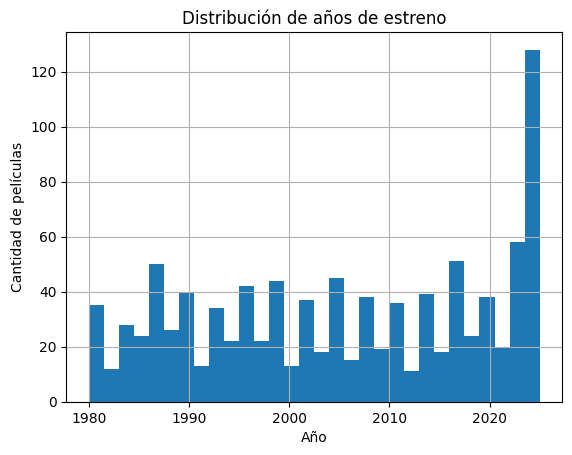

In [87]:
final_movies_df["release_year"].hist(bins=30)
plt.title("Distribución de años de estreno")
plt.xlabel("Año")
plt.ylabel("Cantidad de películas")
plt.show()

La distribución temporal muestra películas desde 1980 hasta la actualidad.

Aunque las películas recientes presentan una mayor representación —algo esperable debido a la naturaleza de TMDB y la disponibilidad de metadata— el corpus conserva diversidad temporal suficiente para evitar un sesgo exclusivo hacia producciones modernas.

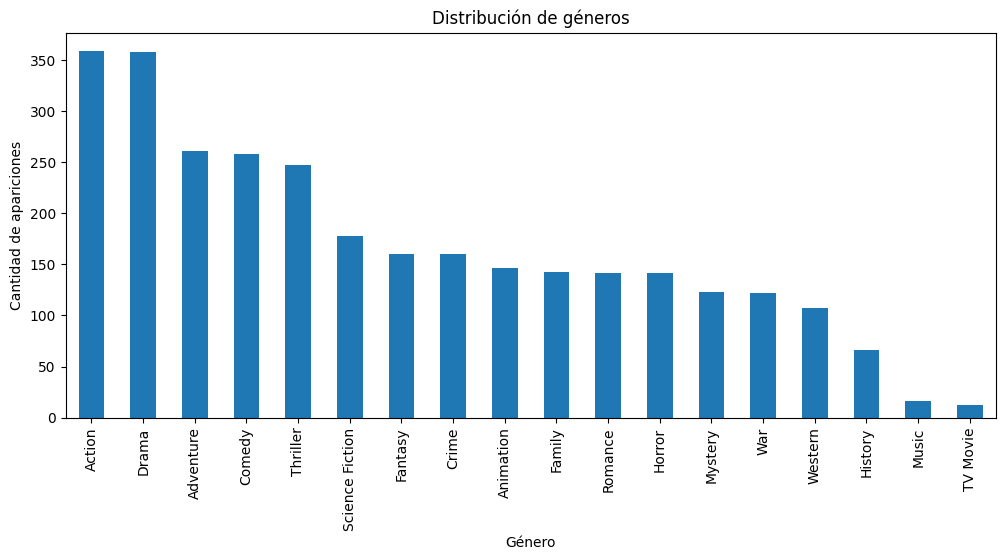

In [88]:
# Como cada película puede tener varios géneros, explotamos la columna genres

genres_exploded = final_movies_df.explode("genres")
genres_exploded["genres"].value_counts().plot(kind="bar", figsize=(12, 5))
plt.title("Distribución de géneros")
plt.xlabel("Género")
plt.ylabel("Cantidad de apariciones")
plt.show()

La distribución de géneros muestra una representación amplia de categorías cinematográficas.

Aunque algunos géneros populares como Action y Drama aparecen con mayor frecuencia —algo esperable debido a la estructura del catálogo de TMDB— el dataset conserva diversidad temática suficiente para construir consultas variadas y evaluar distintos tipos de recuperación.

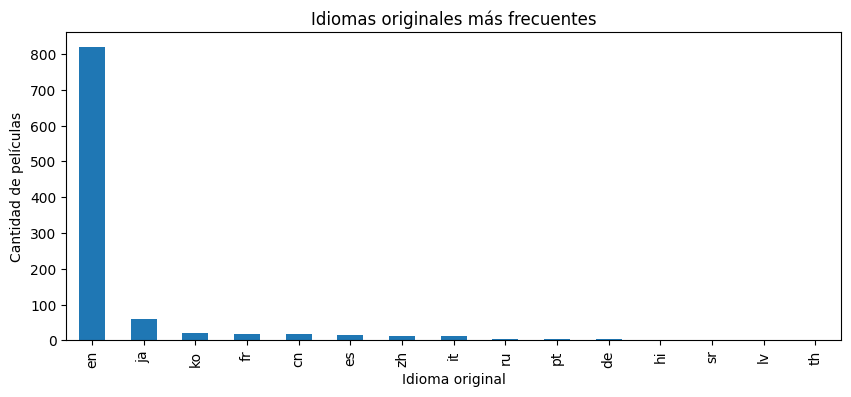

In [89]:
final_movies_df["original_language"].value_counts().head(15).plot(kind="bar", figsize=(10, 4))
plt.title("Idiomas originales más frecuentes")
plt.xlabel("Idioma original")
plt.ylabel("Cantidad de películas")
plt.show()

Aunque la mayoría de las películas presentan metadata textual en inglés, el corpus incluye producciones originalmente creadas en distintos idiomas.

Esto introduce diversidad cultural y narrativa dentro del dataset, manteniendo al mismo tiempo una representación textual consistente para los experimentos de recuperación.

In [92]:
final_movies_df[["popularity", "vote_average", "vote_count"]].describe()

,popularity,vote_average,vote_count
count,1000.000000,1000.000000,1000.000000
mean,10.191802,6.978783,5174.105000
std,14.031209,0.732059,6114.540697
min,0.652700,3.652000,50.000000
25%,4.348225,6.543500,752.250000
50%,7.586850,7.014000,2950.500000
75%,12.180150,7.448500,7298.250000
max,310.271700,8.568000,39574.000000


Las métricas de popularidad y cantidad de votos muestran que el corpus combina películas ampliamente conocidas con otras de popularidad media.

El filtro mínimo de votos permitió evitar registros con metadata pobre o insuficiente, manteniendo al mismo tiempo diversidad temática y temporal dentro del dataset.

## Comparación con el dataset inicial

En el Notebook 1 se trabajó inicialmente con un subconjunto reducido de películas para validar el pipeline de extracción, limpieza y construcción del corpus.

El nuevo dataset amplía significativamente tanto el tamaño como la diversidad del corpus, incorporando:

- mayor variedad de géneros
- películas de distintas décadas
- producciones originalmente creadas en distintos idiomas
- metadata enriquecida (keywords, actores, directores y tagline)

Esta expansión resulta importante para evaluar de manera más realista el comportamiento de los sistemas de recuperación.

En particular, permitirá analizar:

- cuándo TF-IDF funciona correctamente mediante coincidencia léxica,
- cuándo TF-IDF presenta limitaciones,
- y si los embeddings logran recuperar películas relevantes a partir del significado semántico de las consultas y no únicamente por coincidencia exacta de palabras.

Un corpus pequeño y poco diverso puede producir resultados artificialmente buenos en tareas de recuperación, ya que existen menos documentos posibles y menor ambigüedad semántica.

Por esta razón, ampliar y diversificar el dataset permite realizar una evaluación más exigente y representativa del sistema.

## Guardado del dataset expandido

Guardamos el dataset en dos formatos:

- **CSV**: fácil de inspeccionar manualmente.
- **Parquet**: más eficiente y conserva mejor columnas con listas, como `genres`, `keywords`, `cast` y `directors`.

Para los próximos notebooks, se recomienda usar Parquet cuando sea posible.

In [93]:
final_movies_df.to_csv("movies_expanded_1000.csv", index=False)
final_movies_df.to_parquet("movies_expanded_1000.parquet", index=False)

print("Dataset expandido guardado correctamente")

Dataset expandido guardado correctamente


In [94]:
# Verificación de carga
check_df = pd.read_parquet("movies_expanded_1000.parquet")
check_df.head(3)

,id,title,original_title,overview,tagline,release_date,runtime,original_language,genres,keywords,cast,directors,popularity,vote_average,vote_count,overview_length,release_year,search_text,search_text_length
0,10576,Psycho II,Psycho II,Norman Bates is declared sane and released fro...,"It's 22 years later, and Norman Bates is comin...",1983-06-03,113,en,"[Horror, Mystery, Thriller, Crime]","[psychopath, insanity, motel, sequel, revenge,...","[Anthony Perkins, Meg Tilly, Vera Miles, Rober...",[Richard Franklin],2.7056,6.510,724,204,1983,Psycho II | Norman Bates is declared sane and ...,572
1,10830,Matilda,Matilda,Matilda Wormwood is an brilliant and intellige...,Somewhere inside all of us is the power to cha...,1996-08-02,98,en,"[Comedy, Family, Fantasy]","[based on novel or book, parent child relation...","[Mara Wilson, Danny DeVito, Rhea Perlman, Embe...",[Danny DeVito],11.4750,7.174,4785,413,1996,Matilda | Matilda Wormwood is an brilliant and...,1033
2,89,Indiana Jones and the Last Crusade,Indiana Jones and the Last Crusade,"In 1938, an art collector appeals to eminent a...",Have the adventure of your life keeping up wit...,1989-05-24,127,en,"[Adventure, Action]","[saving the world, nazi, holy grail, venice, i...","[Harrison Ford, Sean Connery, Denholm Elliott,...",[Steven Spielberg],7.2998,7.852,11019,625,1989,"Indiana Jones and the Last Crusade | In 1938, ...",1328


In [95]:
# Descargar archivos desde Colab
from google.colab import files

files.download("movies_expanded_1000.csv")
files.download("movies_expanded_1000.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Conclusiones de esta etapa
En este notebook se construyó una versión ampliada y más diversa del dataset de películas.

A diferencia del primer dataset, que servía principalmente para validar el pipeline, esta nueva versión busca representar mejor el espacio de películas disponible mediante una estrategia de balanceo por géneros y años.

Durante esta etapa se realizaron las siguientes tareas:

uso seguro del Bearer Token de TMDB,
obtención de géneros oficiales,
descarga balanceada con discover/movie,
eliminación de duplicados,
filtrado por calidad textual,
enriquecimiento con keywords, elenco y directores,
construcción de search_text,
análisis de diversidad,
exportación del dataset final.
Próximo paso
El siguiente paso del proyecto será volver al baseline TF-IDF y reconstruirlo usando este dataset expandido.

Esto permitirá comparar los resultados del baseline original contra una versión más realista y preparar una base sólida para el Notebook 3 de embeddings.

# Próximo paso

El siguiente paso del proyecto será reconstruir el baseline TF-IDF utilizando este nuevo dataset enriquecido.

Esto permitirá comparar el comportamiento del baseline original frente a un corpus más grande, diverso y semánticamente más rico, preparando además una base sólida para el Notebook 3 dedicado a embeddings multilingües y búsqueda semántica.